## Red Wine Dataset

- Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests. (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).

- The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009].  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

- These datasets can be viewed as classification or regression tasks.  The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods.

- Input Variables based on physicochemical tests :-

1 - fixed acidity
2 - volatile acidity
3 - citric acid
4 - residual sugar
5 - chlorides
6 - free sulfur dioxide
7 - total sulfur dioxide
8 - density
9 - pH
10 - sulphates
11 - alcohol

- Output variable (based on sensory data):

12 - quality (score between 0 and 10)

## Problem Statement

- This project performs Exploratory Data Analysis (EDA) on the Red Wine Quality dataset to understand how different chemical properties influence the quality of wine.

- The objectives of this analysis are:

1. Understand the distribution of wine quality ratings
2. Explore relationships between physicochemical properties and wine quality
3. Identify outliers and anomalies in the dataset
4. Determine the key features that influence wine quality

This analysis helps provide insights into factors contributing to higher-quality wines.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
## Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Loading the Dataset

# path_white_wine = '/content/drive/Othercomputers/My Laptop - HP/Srikant/Red_Wine_Dataset/winequality-white.csv'

# path_red_wine = '/content/drive/Othercomputers/My Laptop - HP/Srikant/Red_Wine_Dataset/winequality-red.csv'

path_redwine = 'winequality-red.csv'

In [4]:
## Loading the dataset

path_redwine = 'winequality-red.csv'

df = pd.read_csv(path_redwine, sep = ';')  # using the separator -> ';' as the csv dataset contains ';' as a seperator and not comma ','.

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [ ]:
## Dataset Overview

# Summary of the entire dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
# Descriptive Statistical Summary of the numerical feautres

df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
# Get the shape of dataset i.e rows and columns of dataset

df.shape  # this shows 1599 rows and 12 columns

(1599, 12)

In [ ]:
## List down all the column names

df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
# Checking the values of a column - 'fixed acidity'

df['fixed acidity']

0        7.4
1        7.8
2        7.8
3       11.2
4        7.4
        ... 
1594     6.2
1595     5.9
1596     6.3
1597     5.9
1598     6.0
Name: fixed acidity, Length: 1599, dtype: float64

In [ ]:
## Checking the unique values of a column

df['fixed acidity'].unique()

array([ 7.4,  7.8, 11.2,  7.9,  7.3,  7.5,  6.7,  5.6,  8.9,  8.5,  8.1,
        7.6,  6.9,  6.3,  7.1,  8.3,  5.2,  5.7,  8.8,  6.8,  4.6,  7.7,
        8.7,  6.4,  6.6,  8.6, 10.2,  7. ,  7.2,  9.3,  8. ,  9.7,  6.2,
        5. ,  4.7,  8.4, 10.1,  9.4,  9. ,  8.2,  6.1,  5.8,  9.2, 11.5,
        5.4,  9.6, 12.8, 11. , 11.6, 12. , 15. , 10.8, 11.1, 10. , 12.5,
       11.8, 10.9, 10.3, 11.4,  9.9, 10.4, 13.3, 10.6,  9.8, 13.4, 10.7,
       11.9, 12.4, 12.2, 13.8,  9.1, 13.5, 10.5, 12.6, 14. , 13.7,  9.5,
       12.7, 12.3, 15.6,  5.3, 11.3, 13. ,  6.5, 12.9, 14.3, 15.5, 11.7,
       13.2, 15.9, 12.1,  5.1,  4.9,  5.9,  6. ,  5.5])

In [ ]:
## checking the count of unique values in a column

df['fixed acidity'].nunique()

96

In [ ]:
## Checking the Quality column

df['quality']

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64

In [ ]:
## Checking what are the Unique Values in Quality column

df['quality'].unique()  # this shows there are 6 unique values in quality column

array([5, 6, 7, 4, 8, 3])

In [ ]:
## Checking the how many or count of unique values in Quality column

df['quality'].nunique()

6

In [ ]:
## Checking the missing values in the dataset

df.isnull().sum()

# this shows that there are no missing values in the dataset

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [ ]:
## Finding out duplicate records in dataset

df.duplicated()

# this shows True in rows where duplicate records are present,
# else shows False in rows where duplicate records are not present

0       False
1       False
2       False
3       False
4        True
        ...  
1594    False
1595    False
1596     True
1597    False
1598    False
Length: 1599, dtype: bool

In [ ]:
## Fetching all the duplicate records present in the dataset

df[df.duplicated()]  # this shows there are total 240 duplicate records in dataset.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


In [ ]:
df.duplicated().sum()  ## this shows the total count of duplicate records - 240

np.int64(240)

In [ ]:
## Removing all the duplicte records from the dataset

df.drop_duplicates(inplace=True) # this function removed all the 240 duplicate records from the dataset permanently

# inplace = True --> this means permanent action

In [ ]:
## Checking if the duplicate records are removed or not

df.shape # by checking the shape we realise that 240 records that were duplicate are removed permanently now. Hence now the total rows - 1359 are left having columns - 12

(1359, 12)

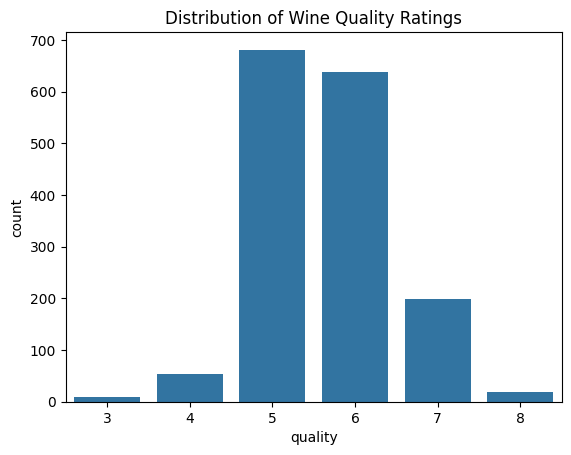

In [ ]:
## Checking Quality Distribution 

sns.countplot(x = 'quality', data = df )
plt.title('Distribution of Wine Quality Ratings')
plt.show()

In [ ]:
## Observations

# 1. The majority of wines have quality ratings between 5 and 6.
# 2. Very few wines have quality ratings above 7.
# 3. Extremely low quality wines having ratings between 3 and 4 are rare.

## Insight

# This suggest that most wines in the dataset fall into the moderate quality category, with relatively few high quality wines.

In [ ]:
## Checking the Correlation of each and every numerical features

df.corr()  # this gives the correlation of each numerical feature with the other numerical feature.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


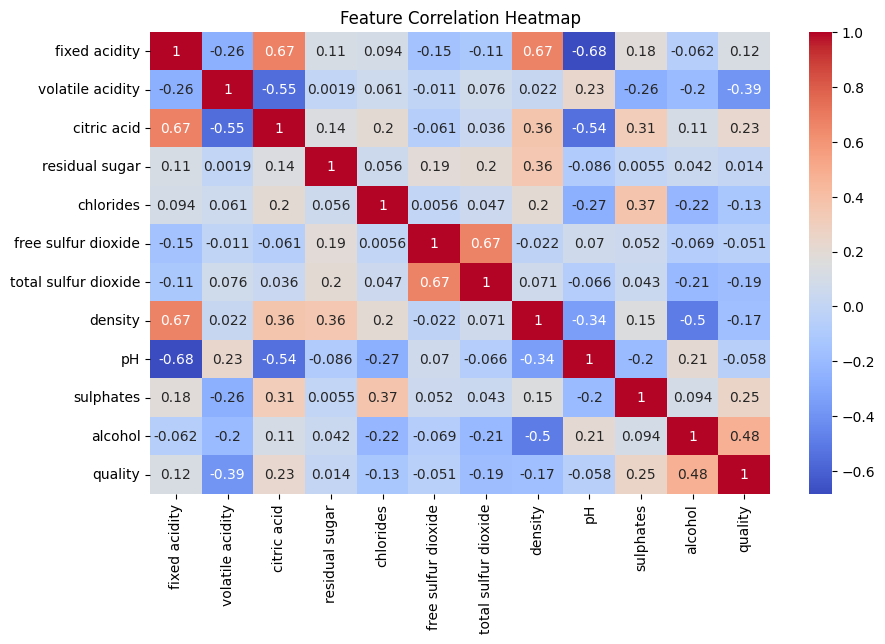

In [12]:
## Plotting the Correlation

# Using heatmap visual for plotting the correlation between numerical features in the dataset

plt.figure(figsize = (10,6))  # this is used to determine the figure size of the visual plot in width and height
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')  # annot = True --> it is used to display the values present in the heatmap blocks
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
## Observation 

# 1. Alcohol vs Quality --> Positive Correlation
# 2. Volalite Acidity vs Quality --> Negative Correlation
# 3. Density vs Alcohol --> Strong Negative Correlation

# Insights 

# 1. Wines with higher alcohol levels tend to have better quality ratings.
# 2. High Volatile Acidity may reduce wine quality.
# 3. Density decreases as alcohol increases.

In [ ]:
## Checking the count of all the unique values in Quality column

df['quality'].value_counts()
 
## this shows that this is an imbalanced dataset because the number or count of categories is not equal with respect to the output categories in quality column.
## With the help of feature engineering we can handle this imbalanced dataset by using SMOTE technique.

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

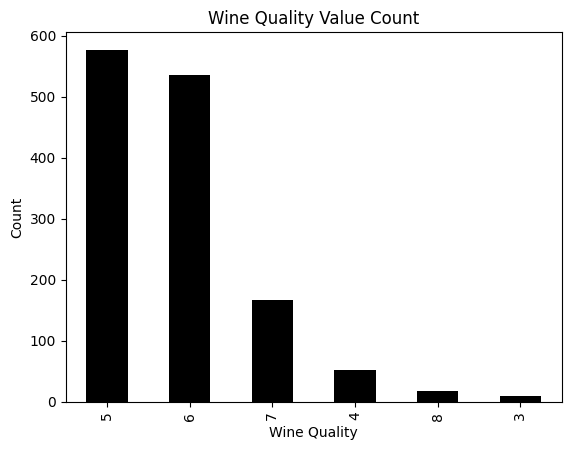

In [ ]:
## Plotting a bar graph as per the value count of all the unique values in quality column

df['quality'].value_counts().plot(kind = 'bar', color = 'black')
plt.xlabel('Wine Quality')
plt.ylabel('Count')
plt.title('Wine Quality Value Count')
plt.show()

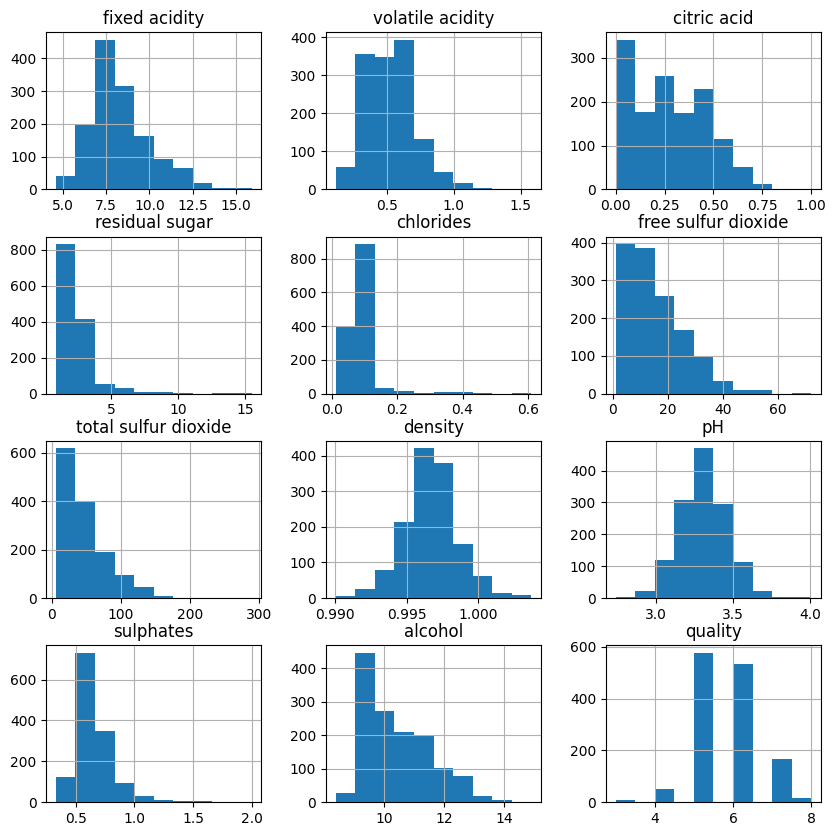

In [ ]:
## Checking the distribution of each and every numerical feature in a dataset

df.hist(figsize = (10,10))
plt.show()

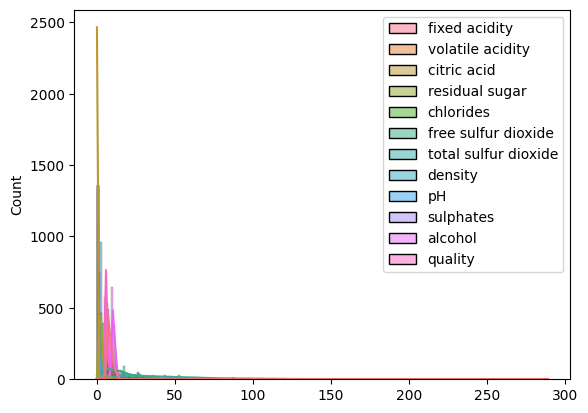

In [ ]:
# this shows the distribution of each numerical feature in the dataset

# the graph has become cluttered because every plot of the respective numerical feature has been overlapped over each other

sns.histplot(df, kde = True)
plt.show()

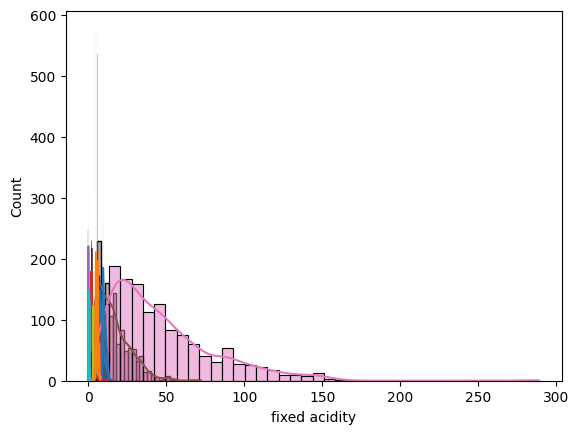

In [ ]:
# this also shows the distribution of each numerical feature in the dataset but in a cluttered way

# the graph has become cluttered because every plot of the respective numerical feature has been overlapped over each other

for column in df.columns :
  sns.histplot(df[column], kde = True)
  # plt.show()

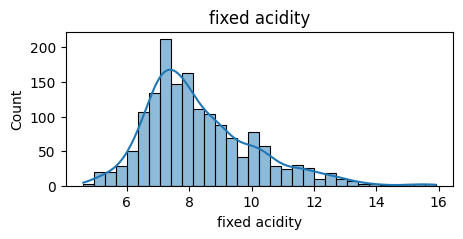

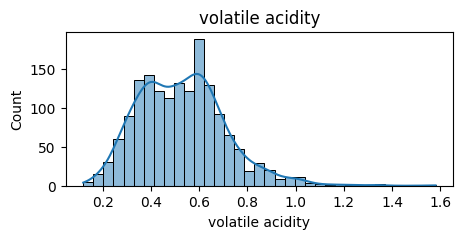

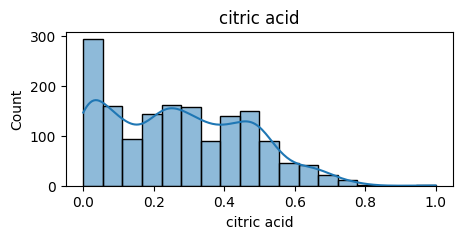

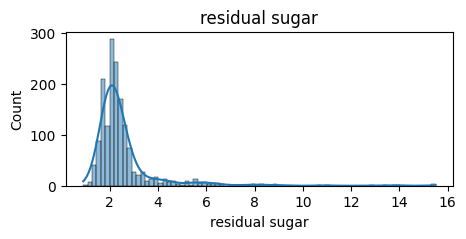

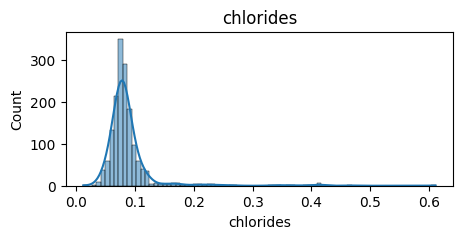

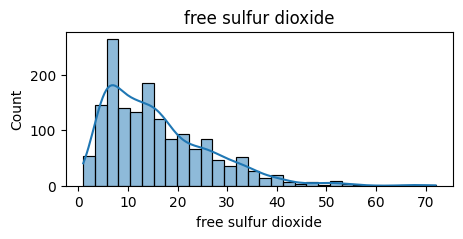

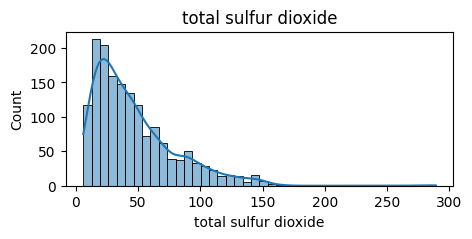

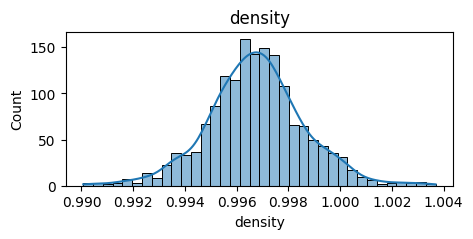

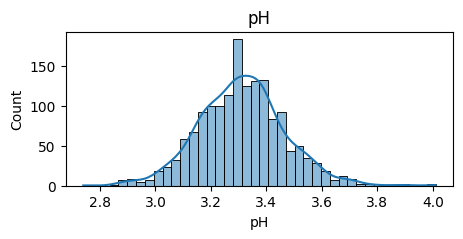

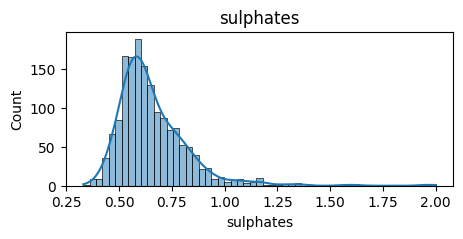

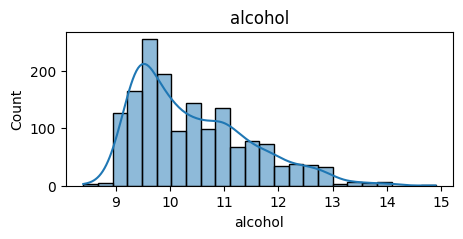

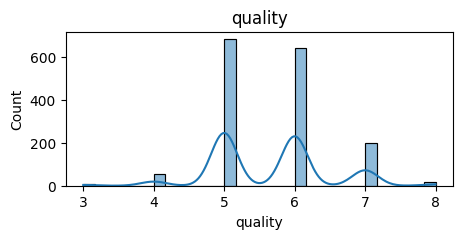

In [ ]:
## Feature Distribution 

# this shows the distribution of each numerical feature in the dataset independently and separately

for columns in df.columns :
  plt.figure(figsize = (5,2))
  sns.histplot(df[columns], kde = True)
  plt.title(columns)
  plt.show()

In [ ]:
## Observations

# Alcohol
# - Alcohol values range from 8% to 14%.
# - Most wines fall between 9% and 11%.

# Residual Sugar
# - Distribution is heavily right skewed.
# - Some wines contain unusually high sugar levels.

# Volatile Acidity
# - Most values cluster between 0.4 and 0.7.

# Insight

# The skewed distributions indicate possible outliers, especially in sugar-related variables.

<Axes: xlabel='fixed acidity', ylabel='Count'>

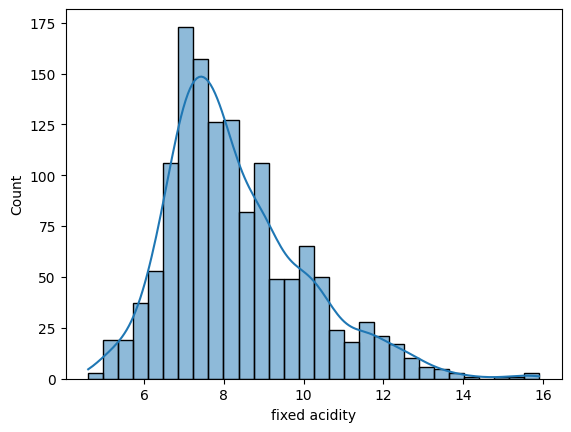

In [ ]:
# Another way to check the distribution of a numerical feature independently one by one

sns.histplot(df['fixed acidity'], kde = True)

# Likewise we can check the distribution of every other numerical feature in the dataset one by one

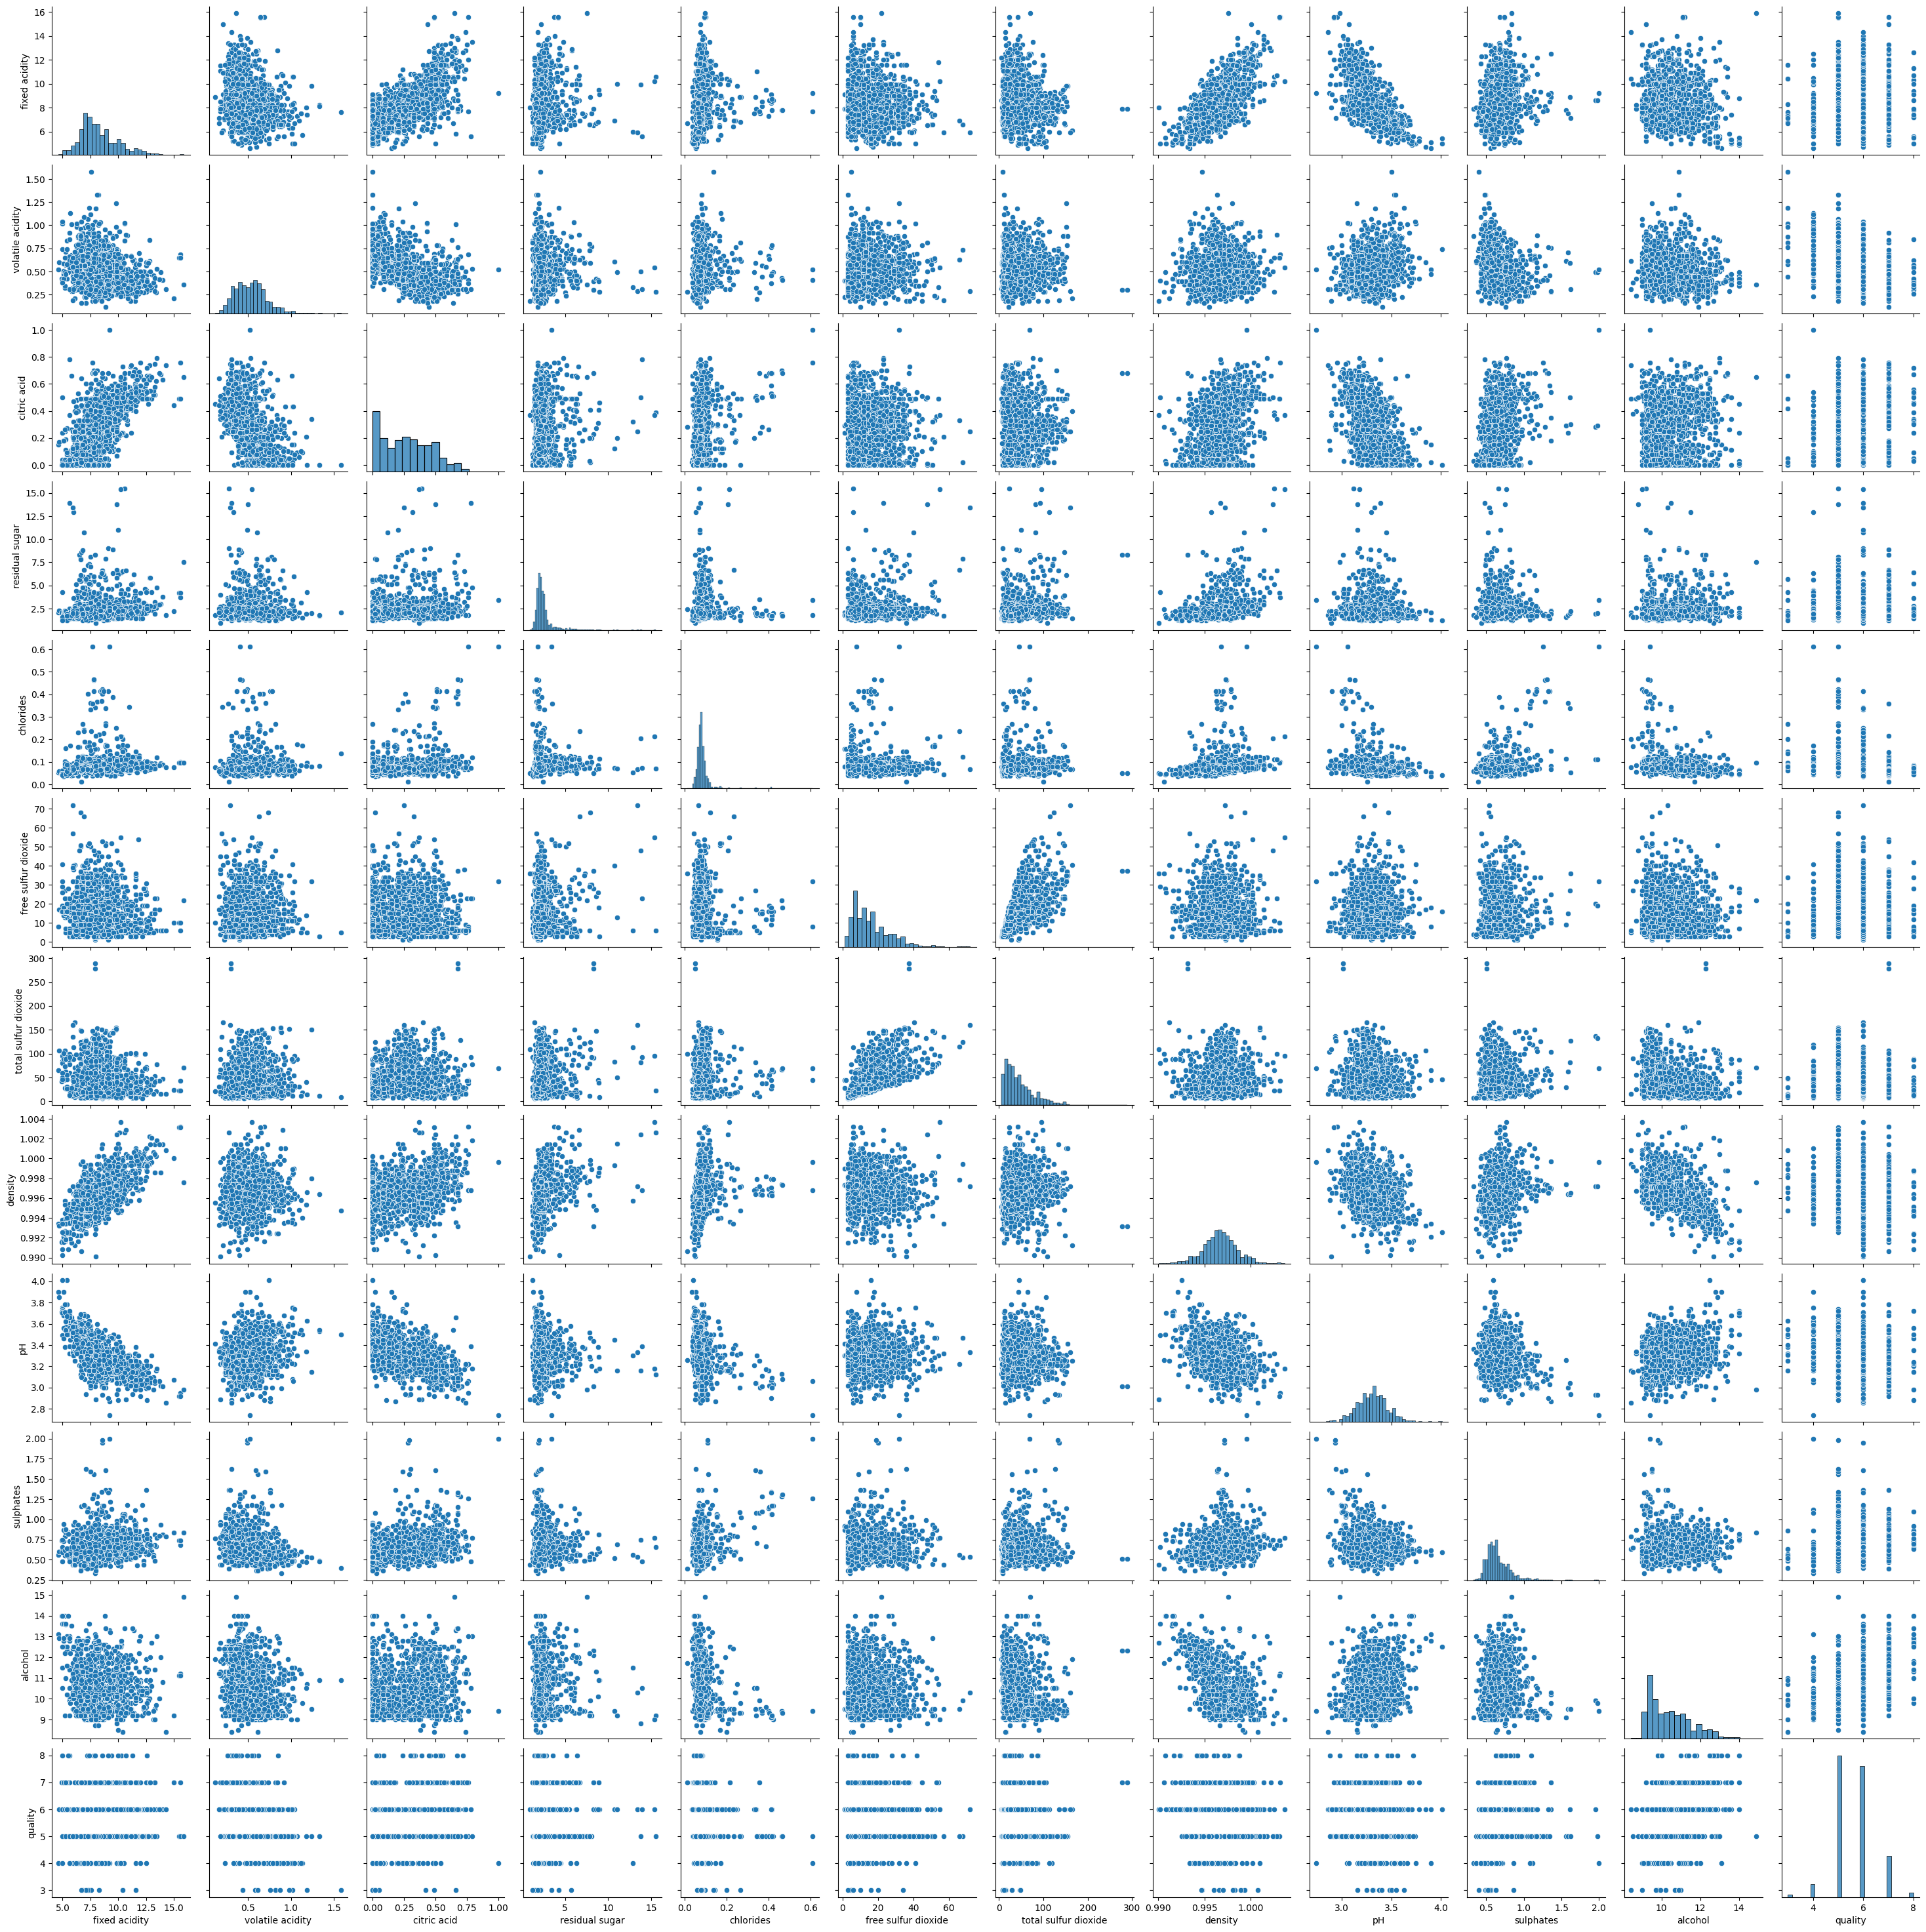

In [ ]:
## Using pairplot to compare one numerical feature with the other for univariate, bivariate and multivariate analysis

# Univariate Analysis - Here we analyze one variable at a time. We study distribution, pattern, spread and summary of a single feature.
# We check - mean, median, mode, standard deviation, distribution shape, outliers, frequency counts.

# Bivariate Analysis - Here we analyze the relationship between two variables.
# We check - Is there any correlation?, Does one variable affect another variable?, Is there any association?
# Types - Numerical vs Numerical, Numerical vs Categorical, Categorical vs Categorical
 
# Multivariate Analysis - Here we analyze more than two variables simultaneously.
# We check - Complex Relationships, Combined Impact, Interactions.

# It shows how each and every feature is correlated with each and every feature in one diagram. Or we can say it compares one feature with the other.

# it takes time while plotting the graph depending upon how many numerical features are there in a dataset.

sns.pairplot(df)

In [ ]:
## Observations

# Alcohol tends to increase with wine quality.
# Volatile acidity tends to decrease as quality increases.

<Figure size 1000x600 with 0 Axes>

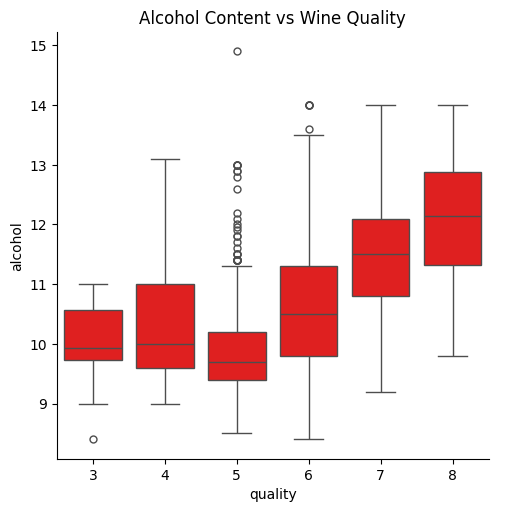

In [19]:
## Plotting a Categorical Plot of the output feature - 'quality' with one of the input feature

# this shows the quartiles along with any outliers ( if present )

plt.figure(figsize=(10,6))
sns.catplot(x = 'quality', y = 'alcohol', data = df, kind = 'box', color = 'red' )
plt.title('Alcohol Content vs Wine Quality')
plt.show()

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


<Axes: xlabel='pH', ylabel='density'>

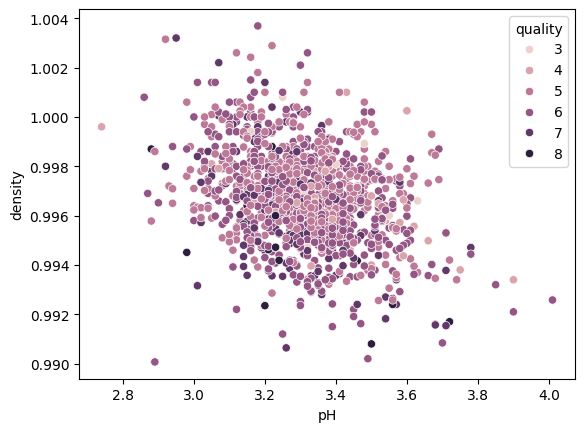

In [ ]:
## Plotting a scatterplot between two variables having quality

sns.scatterplot( x = 'pH' , y = 'density' , data = df , hue = 'quality')

# hue - it add a third variable in the plot by assigning different colors to different categories.
# It is used to add a color gradient or color based grouping in the plot.

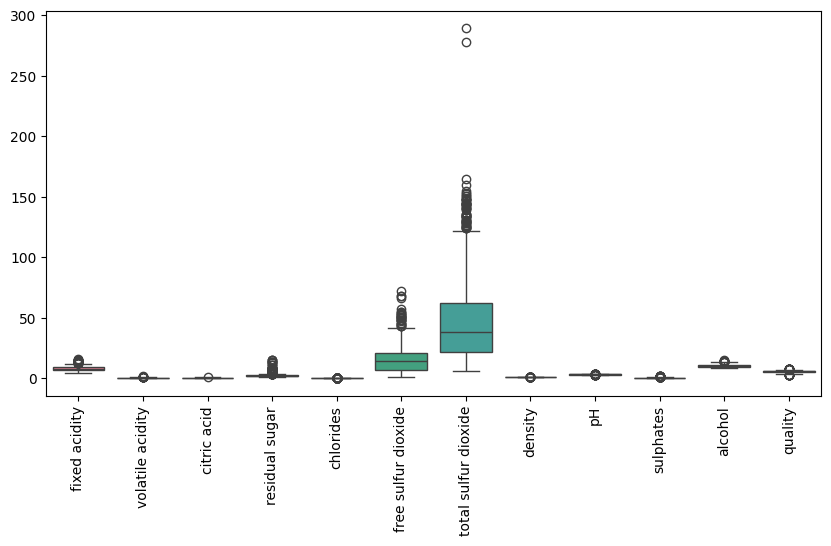

In [10]:
## Outlier Detection

plt.figure(figsize = ( 10, 5 ))
sns.boxplot(data = df)
plt.xticks(rotation = 90)
plt.show()

In [ ]:
## Observations

# Outliers exist in:
# 1. Residual sugar
# 2. Chlorides
# 3. Sulfur dioxide
# 4. Acidity

# Insight

# These outliers indicate significant variation in wine composition.

<Axes: >

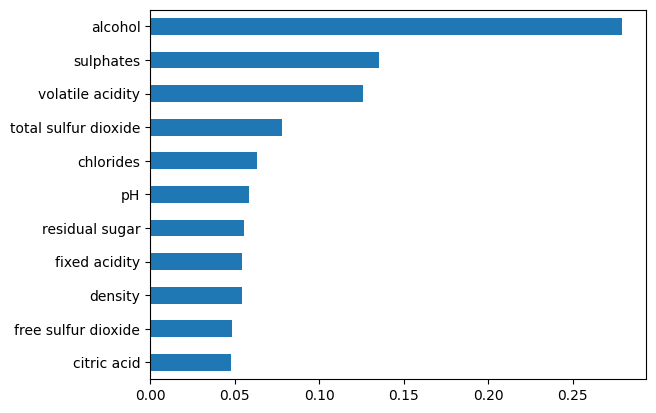

In [ ]:
## Feature Importance

from sklearn.ensemble import RandomForestRegressor

X = df.drop("quality",axis=1)
y = df["quality"]

model = RandomForestRegressor()
model.fit(X,y)

importance = pd.Series(model.feature_importances_,index=X.columns)
importance.sort_values().plot(kind="barh")

In [ ]:
## insights

# The most influential features affecting wine quality are:

# 1. Alcohol
# 2. Volatile acidity
# 3. Sulphates
# 4. Citric acid
# 5. Density

